<a href="https://colab.research.google.com/github/Mithiles-19/OIBSIP/blob/main/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Twitter_Data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
# Remove missing values
df = df.dropna()

# Convert category to integer
df["category"] = df["category"].astype(int)

# Map labels to sentiment names
sentiment_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
df["sentiment"] = df["category"].map(sentiment_map)

df.head()


,clean_text,category,sentiment
0,when modi promised “minimum government maximum...,-1,Negative
1,talk all the nonsense and continue all the dra...,0,Neutral
2,what did just say vote for modi welcome bjp t...,1,Positive
3,asking his supporters prefix chowkidar their n...,1,Positive
4,answer who among these the most powerful world...,1,Positive


In [ ]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts


,count
sentiment,
Positive,72249
Neutral,55211
Negative,35509


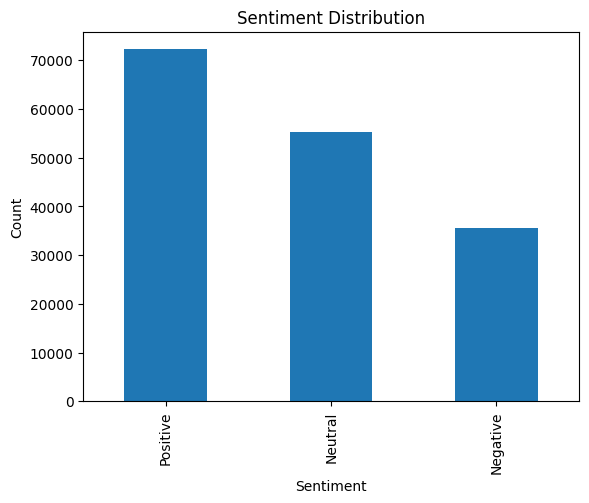

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
sentiment_counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["clean_text"]
y = df["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape


(130375, 5000)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.7164508805301589
              precision    recall  f1-score   support

    Negative       0.82      0.47      0.60      7102
     Neutral       0.77      0.68      0.72     11042
    Positive       0.67      0.87      0.75     14450

    accuracy                           0.72     32594
   macro avg       0.75      0.67      0.69     32594
weighted avg       0.73      0.72      0.71     32594



In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.8536233662637295
              precision    recall  f1-score   support

    Negative       0.86      0.75      0.80      7102
     Neutral       0.80      0.96      0.87     11042
    Positive       0.91      0.82      0.87     14450

    accuracy                           0.85     32594
   macro avg       0.85      0.84      0.84     32594
weighted avg       0.86      0.85      0.85     32594

